In [1]:
import json
from datasets import load_dataset
from openai import OpenAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

## Carregar e dividir os dados entre treino e teste

In [3]:
datasets = load_dataset('hate-speech-portuguese/hate_speech_portuguese',split='train[:10%]')

In [4]:
print(datasets)

Dataset({
    features: ['text', 'label', 'hatespeech_G1', 'annotator_G1', 'hatespeech_G2', 'annotator_G2', 'hatespeech_G3', 'annotator_G3'],
    num_rows: 567
})


In [5]:
datasets = datasets.remove_columns(['hatespeech_G1', 'annotator_G1', 'hatespeech_G2', 'annotator_G2', 'hatespeech_G3', 'annotator_G3'])
print(datasets)

Dataset({
    features: ['text', 'label'],
    num_rows: 567
})


In [6]:
datasets = datasets.train_test_split(test_size=0.2)

In [7]:
datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 453
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 114
    })
})

## Manipular os dados

In [8]:
def removeN(example):
    example['text'] = example['text'].replace("\n"," ")
    return example

In [9]:
datasets = datasets.map(removeN)

Map:   0%|          | 0/453 [00:00<?, ? examples/s]

Map:   0%|          | 0/114 [00:00<?, ? examples/s]

In [10]:
# Garanta que não existam textos vazios ou Nones
datasets = datasets.filter(lambda x: x['text'] is not None and len(str(x['text']).strip()) > 0)

Filter:   0%|          | 0/453 [00:00<?, ? examples/s]

Filter:   0%|          | 0/114 [00:00<?, ? examples/s]

In [11]:
datasets['train'][2]

{'text': 'ANDEI LENDO AQUI NA REDE SOCIAL QUE O SR. ANDA ENGOLINDO MUITA COISA ULTIMAMENTE. O QUE  IMPORTA É SER FELIZ!  ABRAÇO @pecesiqueira #PAZ',
 'label': 0}

In [12]:
# label = 0 -> No Hate Speech
# label = 1 -> Hate Speech

def labelChange(example):
    example['label_text'] = 'No Hate Speech' if example['label'] == 0 else 'Hate Speech'

    return example

In [13]:
datasets = datasets.map(labelChange)
datasets = datasets.remove_columns(['label'])

Map:   0%|          | 0/453 [00:00<?, ? examples/s]

Map:   0%|          | 0/114 [00:00<?, ? examples/s]

In [14]:
print(datasets['train'][0])

{'text': '@amora_inlove Excelente, parabéns! E que venham as mudanças! www.morangoexpress.blogspot.com/', 'label_text': 'No Hate Speech'}


## Transformar no formato que a openai espera

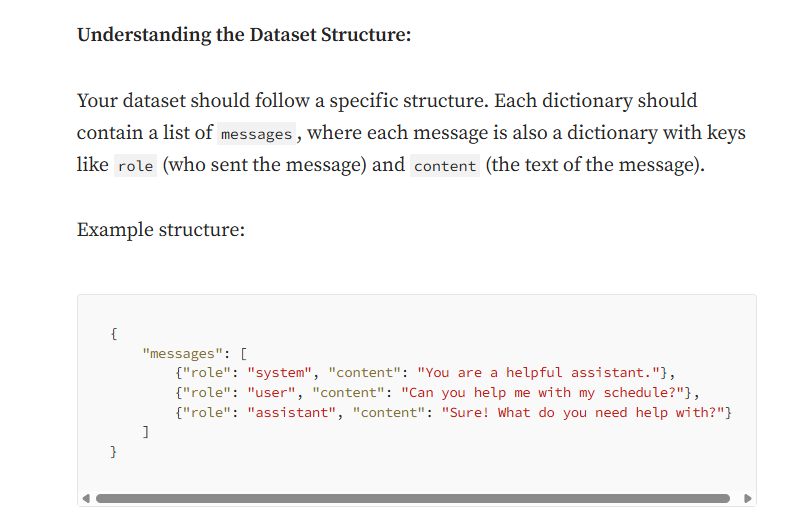

In [15]:
# Construção do objeto para openai
def dataset_to_json(dataset, file_name):
    with open(file_name,'w', encoding='utf-8') as f:
        for example in dataset:
            json_obj = {"messages": [
                {"role": "system", "content": "Você é um classificador especializado em detectar discurso de ódio em português para fins de moderação de conteúdo."},
                {"role": "user", "content": example['text']},
                {"role": "assistant", "content": example['label_text']}
            ]}
            f.write(json.dumps(json_obj, ensure_ascii=False) + '\n')


In [16]:
dataset_to_json(datasets['train'],'trainv1.jsonl')
dataset_to_json(datasets['test'],'validationv1.jsonl')

## Fique de olho nos preços

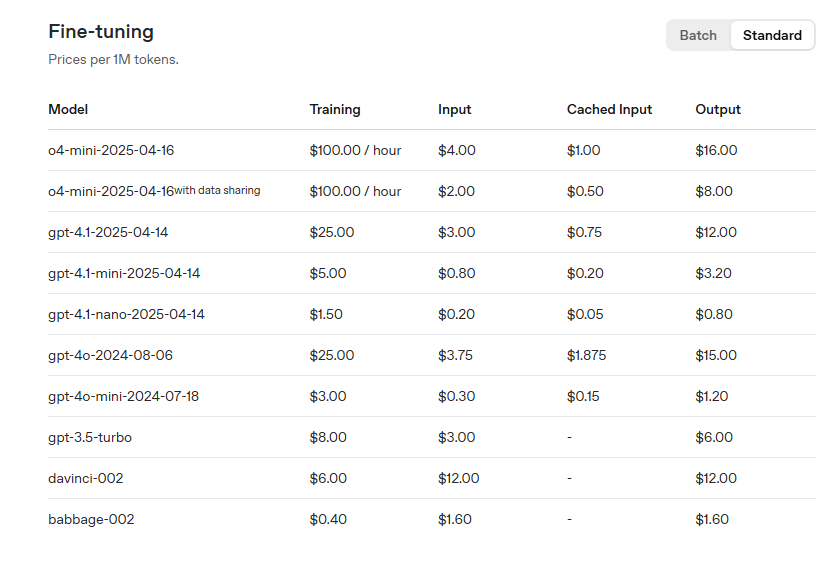

- Link util: https://developers.openai.com/api/docs/guides/direct-preference-optimization/#create-a-dpo-fine-tune-job

In [17]:
client = OpenAI()

In [18]:
client.files.create(
    file=open('trainv1.jsonl','rb'),
    purpose='fine-tune'
)

FileObject(id='file-BawNEqwzxzDwBcnxDrNHpL', bytes=161574, created_at=1773626222, filename='trainv1.jsonl', object='file', purpose='fine-tune', status='processed', status_details=None, expires_at=None)

In [19]:
client.files.create(
    file=open('validationv1.jsonl','rb'),
    purpose='fine-tune'
)

FileObject(id='file-L27GYprymfGzUHfyr9n8xV', bytes=41526, created_at=1773626222, filename='validationv1.jsonl', object='file', purpose='fine-tune', status='processed', status_details=None, expires_at=None)

In [21]:
client.fine_tuning.jobs.create(
    training_file="file-BawNEqwzxzDwBcnxDrNHpL",
    validation_file="file-L27GYprymfGzUHfyr9n8xV",
    model="gpt-3.5-turbo-0125",
)

FineTuningJob(id='ftjob-2YgNTUXJ4Lw6bG6OchqGi29g', created_at=1773626244, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs='auto'), model='gpt-3.5-turbo-0125', object='fine_tuning.job', organization_id='org-WITkELRkwOzsmXE7aX9oCTEj', result_files=[], seed=856381576, status='validating_files', trained_tokens=None, training_file='file-BawNEqwzxzDwBcnxDrNHpL', validation_file='file-L27GYprymfGzUHfyr9n8xV', estimated_finish=None, integrations=[], method=Method(dpo=None, supervised=MethodSupervised(hyperparameters=MethodSupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs='auto')), type='supervised'), user_provided_suffix=None, metadata=None, usage_metrics=None, shared_with_openai=False, eval_id=None, internal_worker_backend=None, internal_peashooter_execution=None, train_experiment_id=None, eval_experiment_id=None)